# Simple predictive model - Random Forest

Why are we using it?

Retrain to 49, then 50.

Pseudo-labelling.

In [38]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import zipfile
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType
from datetime import datetime, timedelta

In [39]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

In [40]:
df_transactions = spark.read.parquet("../data/curated/df_transactions")
df_transactions.show(5)

+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+------------------+--------------+------------------+-----------------------+
|merchant_abn|user_id|order_datetime|       dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|          name|             address|state|postcode|gender|       merchant_name|                tags|            category|revenue_band|take_rate|     total_revenue|n_transactions|   avg_order_value|avg_merchant_fraud_prob|
+------------+-------+--------------+-------------------+--------------------+-----------+------------------+---------------------+--------------+--------------------+-----+--------+------+--------------------+--------------------+--------------------+------------+---------+------------------+

Before creating the Random Forest model, we have to treat create the is_fraud label. In this case, we will need to address the NULL values comming from the average fraud probability.

Merchants unique: 3258
+-----+---------+
|nulls|con_label|
+-----+---------+
| 3213|       45|
+-----+---------+

+-----------------------------------------------------------------------------------------------+-----------------+-----------------+-----------------+
|percentiles                                                                                    |mean             |min              |max              |
+-----------------------------------------------------------------------------------------------+-----------------+-----------------+-----------------+
|[32.99497823665355, 63.21222581102351, 70.16691355669514, 79.18657526947237, 90.52544621880074]|44.53879763316205|18.21089142894488|91.09606847149965|
+-----------------------------------------------------------------------------------------------+-----------------+-----------------+-----------------+



/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


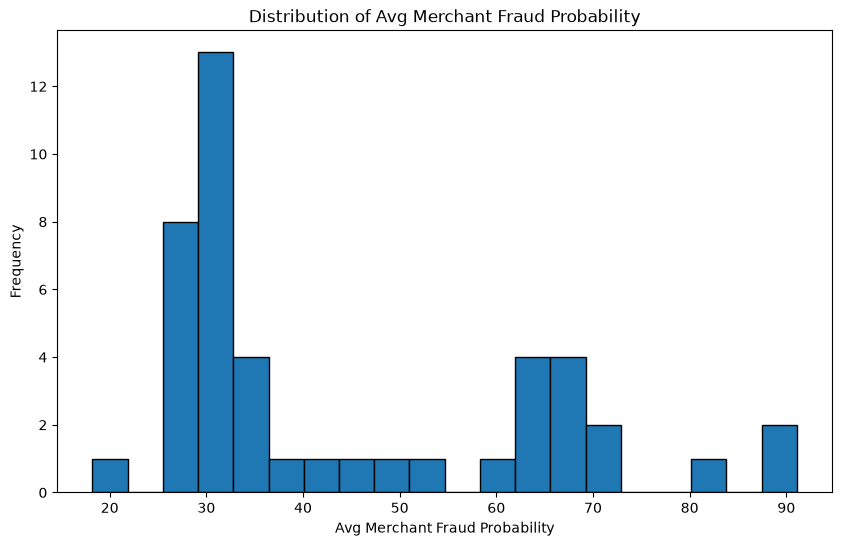

In [41]:
# see ditribution of avg_merchant_fraud_prob
merchant_level = df_transactions.select(
    "merchant_abn", "avg_merchant_fraud_prob"
).dropDuplicates(["merchant_abn"])

print(f"Merchants unique: {merchant_level.count()}")

# Nulls
merchant_level.select(
    F.count(F.when(F.col("avg_merchant_fraud_prob").isNull(), True)).alias("nulls"),
    F.count(F.when(F.col("avg_merchant_fraud_prob").isNotNull(), True)).alias("con_label")
).show()

# Percentiles of the merchants with label (avg_merchant_fraud_prob not null)
merchant_level.filter(F.col("avg_merchant_fraud_prob").isNotNull()).select(
    F.expr("percentile(avg_merchant_fraud_prob, array(0.5, 0.75, 0.90, 0.95, 0.99))").alias("percentiles"),
    F.mean("avg_merchant_fraud_prob").alias("mean"),
    F.min("avg_merchant_fraud_prob").alias("min"),
    F.max("avg_merchant_fraud_prob").alias("max")
).show(truncate=False)

# Histogram
pdf_merchant = merchant_level.filter(F.col("avg_merchant_fraud_prob").isNotNull()) \
    .select("avg_merchant_fraud_prob").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_merchant["avg_merchant_fraud_prob"], bins=20, edgecolor="black")
plt.xlabel("Avg Merchant Fraud Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Merchant Fraud Probability")
plt.show()

Before deciding the threshold, we will observe the number of merchants depending on the percentile.

In [42]:
# merchants with fraud probability label (avg_merchant_fraud_prob not null)
labeled_merchants = merchant_level.filter(F.col("avg_merchant_fraud_prob").isNotNull())

# test different thresholds to flag merchants
thresholds = [20, 25, 30, 31, 32.99, 40, 44.5, 50, 63.2, 70]

# see the percentage of merchants flagged for each threshold
for t in thresholds:
    n_flagged = labeled_merchants.filter(F.col("avg_merchant_fraud_prob") > t).count()
    total = labeled_merchants.count()
    print(f"threshold > {t}: {n_flagged}/{total} flagged ({n_flagged/total:.1%})")

threshold > 20: 44/45 flagged (97.8%)
threshold > 25: 44/45 flagged (97.8%)
threshold > 30: 32/45 flagged (71.1%)
threshold > 31: 29/45 flagged (64.4%)
threshold > 32.99: 23/45 flagged (51.1%)
threshold > 40: 18/45 flagged (40.0%)
threshold > 44.5: 16/45 flagged (35.6%)
threshold > 50: 15/45 flagged (33.3%)
threshold > 63.2: 12/45 flagged (26.7%)
threshold > 70: 5/45 flagged (11.1%)


In [43]:
# understand the gaps between avg_merchant_fraud_prob values to find a good threshold
pdf_merchant_sorted = pdf_merchant.sort_values("avg_merchant_fraud_prob").reset_index(drop=True)
pdf_merchant_sorted["gap_to_next"] = pdf_merchant_sorted["avg_merchant_fraud_prob"].diff()

# top 10 merchants with the largest gap to the next merchant
top_gaps = pdf_merchant_sorted.nlargest(10, "gap_to_next")

# print the top gaps
for idx in top_gaps.index:
    val_after = pdf_merchant_sorted.loc[idx, "avg_merchant_fraud_prob"]
    val_before = pdf_merchant_sorted.loc[idx - 1, "avg_merchant_fraud_prob"]
    gap = pdf_merchant_sorted.loc[idx, "gap_to_next"]
    print(f"{val_before:.2f}   {val_after:.2f}   (gap = {gap:.2f})")

18.21   28.50   (gap = 10.29)
80.80   89.80   (gap = 9.00)
53.29   61.92   (gap = 8.64)
72.73   80.80   (gap = 8.07)
44.01   48.67   (gap = 4.66)
48.67   53.29   (gap = 4.62)
36.99   40.73   (gap = 3.75)
40.73   44.01   (gap = 3.28)
65.01   67.12   (gap = 2.11)
70.88   72.73   (gap = 1.85)


In [44]:
top_gaps = pdf_merchant_sorted.nlargest(4, "gap_to_next")
for idx in top_gaps.index:
    n_low = idx  # merchants before the gap
    n_high = len(pdf_merchant_sorted) - idx
    print(f"gap={pdf_merchant_sorted.loc[idx,'gap_to_next']:.2f} groups: {n_low} vs {n_high}")

gap=10.29 groups: 1 vs 44
gap=9.00 groups: 43 vs 2
gap=8.64 groups: 31 vs 14
gap=8.07 groups: 42 vs 3


The point were we can separate the fraud probability from low to high, while being able to capture a reasonable amount of merchants is between 53.29 and 61.92, since the groups get splitted into 31 merchants with no fraud, and 14 with fraud.

In [45]:
# threshold between the two largest gaps already established
threshold_merchant = (53.286933 + 61.923809) / 2 

pdf_merchant["is_fraud"] = (pdf_merchant["avg_merchant_fraud_prob"] > threshold_merchant).astype(int)

print(pdf_merchant["is_fraud"].value_counts())
print(f"% fraude: {pdf_merchant['is_fraud'].mean():.1%}")

is_fraud
0    31
1    14
Name: count, dtype: int64
% fraude: 31.1%


In [46]:
# proceed to do the split of the dataset
from sklearn.model_selection import train_test_split

# split the dataset into train and test sets, stratifying by the is_fraud label
train, test = train_test_split(
    pdf_merchant, test_size=0.3, random_state=42, stratify=pdf_merchant["is_fraud"]
)

print(f"Train set: {len(train)} samples, {train['is_fraud'].mean():.1%} fraud")
print(f"Test set: {len(test)} samples, {test['is_fraud'].mean():.1%} fraud")

Train set: 31 samples, 32.3% fraud
Test set: 14 samples, 28.6% fraud


In [47]:
merchant_level = df_transactions.select(
    "merchant_abn", "category", "revenue_band", "take_rate",
    "avg_order_value", "n_transactions", "total_revenue", "avg_merchant_fraud_prob"
).dropDuplicates(["merchant_abn"])

print(f"Merchants únicos: {merchant_level.count()}")  # debería ser ~4,026

pdf_merchant = merchant_level.toPandas()

Merchants únicos: 3258


/home/pau_l/project-2/venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Since having large trees with a small dataset, could result in overfitting, we will instead used Logistics Regression.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

seed = 42 
# categoriacal and numerical columns
cat_cols = ["category", "revenue_band"]
num_cols = ["take_rate", "avg_order_value", "n_transactions", "total_revenue"]

# create a pipeline with preprocessing and logistic regression
# use OneHotEncoder for categorical variables and StandardScaler for numerical variables
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# create a pipeline with preprocessing and logistic regression
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# cross-validation on the train set (32 points) instead of relying on a single fit
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, seed[cat_cols + num_cols], seed["is_fraud_label"],
                          cv=cv, scoring="roc_auc")

print(f"CV ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

TypeError: 'int' object is not subscriptable

In [ ]:
df_transactions.printSchema()

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)

